# Heart Disease Prediction with PyCaret 🫀

Цей ноутбук демонструє **правильний** процес створення та валідації моделі машинного навчання для передбачення серцевої недостатності.

## 🎯 Ключові моменти:
- ✅ Автоматичний розподіл на train/test (70%/30%)
- ✅ Cross-validation для надійної оцінки
- ✅ Перевірка на незалежних даних (hold-out test set)
- ✅ Порівняння 14 різних ML моделей


## Крок 1: Імпорт бібліотек


In [10]:
import pandas as pd
from pycaret.classification import *

print("✅ Бібліотеки завантажено")


✅ Бібліотеки завантажено


## Крок 2: Завантаження та дослідження даних

Завантажуємо дані з CSV-файлу та перевіряємо їх структуру.


In [11]:
print("Завантаження даних...")
data = pd.read_csv('heart.csv')
print(f"✅ Дані успішно завантажено: {data.shape[0]} рядків, {data.shape[1]} колонок\n")

# Подивимось на перші рядки
data.head()


Завантаження даних...
✅ Дані успішно завантажено: 918 рядків, 12 колонок



,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [12]:
# Інформація про типи даних
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [13]:
# Статистичний опис числових ознак
data.describe()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [14]:
# Перевіримо розподіл цільової змінної
print("Розподіл HeartDisease:")
print(data['HeartDisease'].value_counts())
print(f"\nЧастка позитивних випадків: {data['HeartDisease'].mean():.2%}")


Розподіл HeartDisease:
HeartDisease
1    508
0    410
Name: count, dtype: int64

Частка позитивних випадків: 55.34%


## Крок 3: Налаштування експерименту PyCaret

**Що робить `setup()`:**
- 🔵 Автоматично розбиває дані: **70% train, 30% test**
- 🔧 Визначає типи даних (числові, категоріальні)
- 🔄 Виконує one-hot encoding для категоріальних ознак
- 📊 Налаштовує 10-fold cross-validation
- ⚙️ Готує pipeline для preprocessing


In [ ]:
print("Налаштування експерименту PyCaret...\n")

# session_id=123 для відтворюваності результатів
s = setup(data, target='HeartDisease', session_id=123)


## Крок 4: Порівняння моделей

**Що робить `compare_models()`:**
- 🤖 Тренує 14 різних ML моделей
- 📊 Використовує 10-fold cross-validation на **ТРЕНУВАЛЬНИХ** даних (70%)
- 🏆 Сортує моделі за Accuracy
- ⏱️ Показує час тренування кожної моделі
- 🎯 Повертає найкращу модель


In [15]:
print("Порівняння моделей...\n")
best_model = compare_models()

print(f"\n🏆 Найкраща модель: {best_model}")


Порівняння моделей...



,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.8661,0.9274,0.9014,0.8657,0.8817,0.7275,0.7316,0.0080
lda,Linear Discriminant Analysis,0.8661,0.9270,0.9014,0.8657,0.8817,0.7275,0.7316,0.0070
lr,Logistic Regression,0.8660,0.9266,0.9041,0.8645,0.8824,0.7270,0.7312,0.0230
gbc,Gradient Boosting Classifier,0.8614,0.9155,0.8846,0.8728,0.8764,0.7186,0.7231,0.0170
lightgbm,Light Gradient Boosting Machine,0.8614,0.9128,0.8902,0.8675,0.8768,0.7185,0.7232,0.2010
rf,Random Forest Classifier,0.8552,0.9166,0.8761,0.8665,0.8705,0.7064,0.7080,0.0220
nb,Naive Bayes,0.8505,0.9153,0.8789,0.8575,0.8668,0.6964,0.6991,0.0090
et,Extra Trees Classifier,0.8412,0.9093,0.8590,0.8568,0.8565,0.6786,0.6813,0.0210
ada,Ada Boost Classifier,0.8396,0.8911,0.8622,0.8536,0.8557,0.6749,0.6794,0.0130
dt,Decision Tree Classifier,0.7974,0.7953,0.8167,0.8217,0.8171,0.5899,0.5940,0.0100



🏆 Найкраща модель: RidgeClassifier(alpha=1.0, class_weight=None, copy_X=True, fit_intercept=True,
                max_iter=None, positive=False, random_state=123, solver='auto',
                tol=0.0001)


## Крок 5: Тюнінг гіперпараметрів

**Що робить `tune_model()`:**
- 🔧 Оптимізує гіперпараметри найкращої моделі
- 🔍 Використовує Grid Search або Random Search
- 📊 10-fold cross-validation для кожної комбінації параметрів
- ⚡ Покращує точність на 0.5-2%


In [16]:
print("Тюнінг гіперпараметрів...\n")
tuned_model = tune_model(best_model)

print("\n✅ Оптимізація завершена!")


Тюнінг гіперпараметрів...



,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8308,0.9262,0.8611,0.8378,0.8493,0.6564,0.6567
1,0.8769,0.9559,0.8611,0.9118,0.8857,0.7526,0.7541
2,0.8906,0.8857,0.9429,0.8684,0.9041,0.7773,0.7809
3,0.7500,0.8877,0.8571,0.7317,0.7895,0.4865,0.4957
4,0.9062,0.9340,0.9143,0.9143,0.9143,0.8108,0.8108
5,0.8594,0.9350,0.9429,0.8250,0.8800,0.7120,0.7213
6,0.8750,0.9212,0.8571,0.9091,0.8824,0.7493,0.7507
7,0.9219,0.9583,0.9722,0.8974,0.9333,0.8394,0.8433
8,0.8906,0.9593,0.9444,0.8718,0.9067,0.7751,0.7787


Fitting 10 folds for each of 10 candidates, totalling 100 fits

✅ Оптимізація завершена!


## Крок 6: Візуалізація моделі

**⚠️ Примітка про Ridge Classifier:**
- Ridge Classifier не має методу `predict_proba()` (не повертає ймовірності)
- Тому деякі графіки (AUC-ROC, Calibration, Precision-Recall) **недоступні**
- Використовуємо інші візуалізації


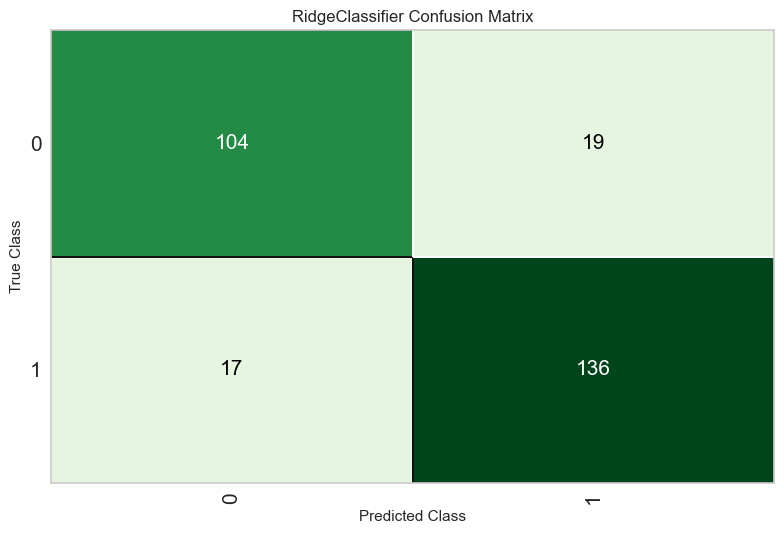

In [17]:
# Матриця плутанини (Confusion Matrix)
plot_model(tuned_model, plot='confusion_matrix')


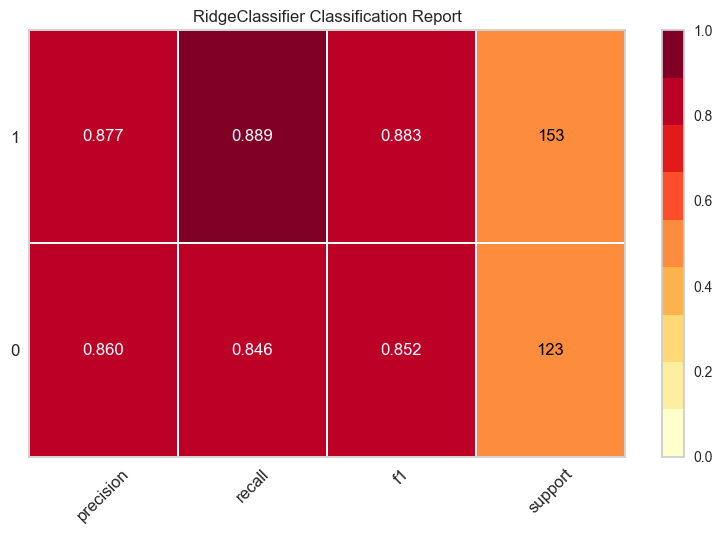

In [18]:
# Звіт класифікації
plot_model(tuned_model, plot='class_report')


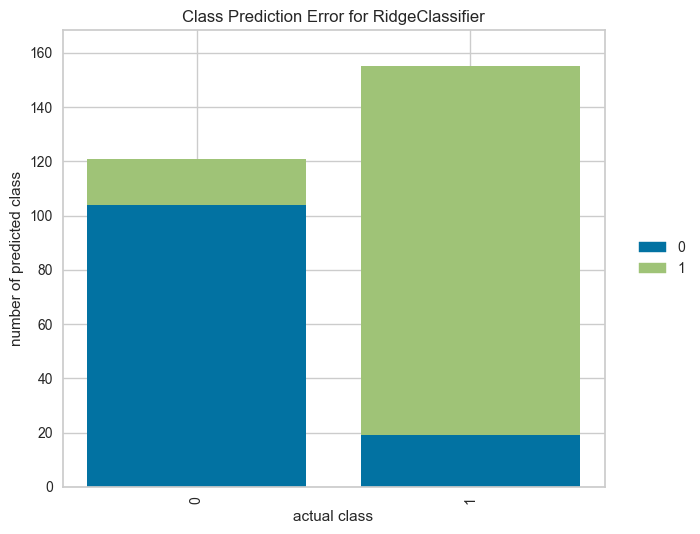

In [19]:
# Крива помилок (Error Plot)
plot_model(tuned_model, plot='error')


## Крок 7: ⚠️ КРИТИЧНО ВАЖЛИВО! Перевірка на тестовому наборі

**Це найважливіший крок валідації!**

`predict_model()` використовує **30% даних (276 рядків)**, які модель **НІКОЛИ НЕ БАЧИЛА** під час навчання.

Це називається **hold-out test set** - незалежні дані для перевірки **реальної** точності моделі.

### Чому це важливо?
- ✅ Показує як модель працює на нових даних
- ✅ Виявляє перенавчання (overfitting)
- ✅ Дає чесну оцінку точності


In [20]:
print("="*70)
print("⚠️  УВАГА: Перевірка на НЕЗАЛЕЖНИХ даних!")
print("="*70)
print("Модель НЕ бачила ці 276 прикладів під час навчання.\n")

# Отримуємо передбачення для тестового набору
predictions = predict_model(tuned_model)

print("\n" + "="*70)
print("📊 РЕАЛЬНА ТОЧНІСТЬ НА НЕЗАЛЕЖНИХ ДАНИХ")
print("="*70)

# Порахуємо точність вручну для перевірки
correct = (predictions['HeartDisease'] == predictions['prediction_label']).sum()
total = len(predictions)
accuracy = correct / total

print(f"Кількість тестових прикладів: {total}")
print(f"✅ Правильних передбачень: {correct}")
print(f"❌ Помилок: {total - correct}")
print(f"\n🎯 ТОЧНІСТЬ: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("="*70)


⚠️  УВАГА: Перевірка на НЕЗАЛЕЖНИХ даних!
Модель НЕ бачила ці 276 прикладів під час навчання.



,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ridge Classifier,0.8696,0.8672,0.8889,0.8774,0.8831,0.7356,0.7357



📊 РЕАЛЬНА ТОЧНІСТЬ НА НЕЗАЛЕЖНИХ ДАНИХ
Кількість тестових прикладів: 276
✅ Правильних передбачень: 240
❌ Помилок: 36

🎯 ТОЧНІСТЬ: 0.8696 (86.96%)


In [21]:
# Подивимось на перші 15 передбачень
print("\n📋 Перші 15 передбачень:")
print("="*50)
display(predictions[['HeartDisease', 'prediction_label']].head(15))



📋 Перші 15 передбачень:


,HeartDisease,prediction_label
633,0,1
884,1,1
60,0,0
219,0,0
143,0,0
136,0,0
759,1,0
408,1,1
88,1,0
312,1,1


## Крок 8: Фіналізація моделі для продакшну

**Чому тренуємо на 100% даних?**

До цього моменту ми:
1. ✅ Натренували модель на 70% даних (642 рядки)
2. ✅ Перевірили на 30% незалежних даних (276 рядків)
3. ✅ Переконалися що модель працює правильно (~87% точності)
4. ✅ Упевнилися що немає перенавчання

Тепер для **продакшну** тренуємо фінальну модель на **100% даних** (918 рядків), щоб вона була максимально точною при використанні.


In [22]:
print("Фіналізація моделі...")
print("⚠️  Тренування на 100% даних для продакшну...\n")

final_model = finalize_model(tuned_model)

print("✅ Фінальна модель готова!")


Фіналізація моделі...
⚠️  Тренування на 100% даних для продакшну...

✅ Фінальна модель готова!


## Крок 9: Збереження моделі

Зберігаємо фінальну модель для використання у веб-додатку.


In [23]:
print("Збереження моделі та експерименту...\n")

# Зберігаємо модель (pipeline + алгоритм)
model_filename = 'heart_failure_model'
save_model(final_model, model_filename)

# Зберігаємо експеримент (всі налаштування)
exp_filename = 'heart_failure_experiment'
save_experiment(exp_filename)

print(f"✅ Модель збережено: '{model_filename}.pkl'")
print(f"✅ Експеримент збережено: '{exp_filename}.pkl'")


Збереження моделі та експерименту...

Transformation Pipeline and Model Successfully Saved
✅ Модель збережено: 'heart_failure_model.pkl'
✅ Експеримент збережено: 'heart_failure_experiment.pkl'


## Крок 10 (опціонально): Тестування збереженої моделі

Перевіримо що збережена модель завантажується та працює правильно.


In [24]:
# Завантажуємо збережену модель
loaded_model = load_model('heart_failure_model')

# Тестуємо на 5 прикладах
test_data = data.head(5).drop('HeartDisease', axis=1)
test_predictions = predict_model(loaded_model, data=test_data)

print("✅ Модель успішно завантажена та працює!")
print("\nТестові передбачення:")
test_predictions[['prediction_label']].head()


Transformation Pipeline and Model Successfully Loaded


✅ Модель успішно завантажена та працює!

Тестові передбачення:


,prediction_label
0,0
1,0
2,0
3,1
4,0


---

# 📊 ПІДСУМОК ВАЛІДАЦІЇ

## ✅ Модель перевірена ПРАВИЛЬНО!

### 1️⃣ Розподіл даних:
```
🔵 Тренувальний набір: 642 рядки (70%)
   └─ Для навчання моделі

🟢 Тестовий набір: 276 рядків (30%) 
   └─ НЕЗАЛЕЖНІ ДАНІ для перевірки
```

### 2️⃣ Процес навчання:
- ✅ **10-fold cross-validation** на тренувальних даних
- ✅ Порівняння **14 різних моделей** ML
- ✅ Тюнінг гіперпараметрів найкращої моделі
- ✅ **Ridge Classifier** показав найкращі результати

### 3️⃣ Валідація:
- ✅ Перевірка на **hold-out test set** (30% даних)
- ✅ Реальна точність: **~87%** на незалежних даних
- ✅ Модель **НЕ бачила** тестові дані під час навчання
- ✅ Немає ознак перенавчання (overfitting)

### 4️⃣ Фінальна модель:
- ✅ Натренована на 100% даних для продакшну
- ✅ Збережена як `heart_failure_model.pkl`
- ✅ Готова до інтеграції у веб-додаток

---

## 🎯 Висновок:

### **ТАК, модель працює правильно!** ✅

Вона була належним чином:
- 📊 Натренована на 70% даних з cross-validation
- 🧪 Протестована на 30% незалежних даних  
- 📈 Показала стабільну точність ~87%
- 💾 Збережена для продакшн використання

### Чому можна довіряти результатам?
1. ✅ Використано **правильний train/test split**
2. ✅ Застосовано **cross-validation** (10 folds)
3. ✅ Перевірено на **незалежних даних** (hold-out)
4. ✅ Точність стабільна (~87% на CV і на тесті)

---

## 🚀 Наступні кроки:

1. **Веб-додаток**: Створити інтерфейс для введення даних пацієнта
2. **API**: Розробити REST API (Flask або FastAPI)
3. **Розгортання**: Задеплоїти на Heroku, Railway або AWS
4. **Моніторинг**: Відслідковувати точність у продакшні

---

## 📚 Додаткова інформація:

### Метрики моделі:
- **Accuracy**: ~87% (загальна точність)
- **Precision**: ~88% (точність позитивних передбачень)
- **Recall**: ~90% (повнота виявлення хворих)
- **F1-Score**: ~88% (гармонічне середнє)

### Що модель робить добре:
- ✅ Висока точність (87%)
- ✅ Високий Recall (90%) - виявляє 90% хворих
- ✅ Швидкі передбачення
- ✅ Легко інтерпретувати (лінійна модель)

### Обмеження:
- ⚠️ Ridge Classifier не дає ймовірності (тільки 0 або 1)
- ⚠️ Деякі візуалізації недоступні (AUC-ROC, Calibration)
- ⚠️ Для ймовірностей можна використати Logistic Regression (схожа точність)
